# PINN Solution for 1D Burgers Equation

Steps for solving PINNs

* Define neural network
* Define the initial conditions (IC) and boundary conditions (BC)
* Set the optimizers
* Define the loss function
* Run the training loop
* Restult post-processing


Recall the 1D Burgers Equation

\begin{equation}
    \begin{split}
        \frac{\partial u}{\partial t} \,\, + \,\, u \frac{\partial u}{\partial x} \quad &= \quad \nu \frac{\partial^2 u}{\partial x^2} \\[2em]
    \end{split}
\end{equation}

In [1]:
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#from tqdm import tqdm

import torch
import torch.nn as nn

## Define the neural network

In [2]:
# Define neural network class

class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.net = torch.nn.Sequential(
            nn.Linear(2,20),                    # Input layer, starting with 2 inputs and expanding to 20 nodes in the first layer
            nn.Tanh(),                          # activation function
            nn.Linear(20,30),                   # 1st layer, expanding from 20 noes in the first layer to 30 nodes in second layer
            nn.Tanh(),
            nn.Linear(30,30),                   # 2nd layer
            nn.Tanh(),
            nn.Linear(30,20),                   # 3rd layer
            nn.Tanh(),
            nn.Linear(20,20),                   # 4th layer
            nn.Tanh(),
            nn.Linear(20,1)                     # finally reduce the 20 nodes of the last layer to 1 output node
        )
    
    def forward(self, x):
        out = self.net(x)
        return out

## Initial Conditions and Boundary Conditions

In [3]:
class Net:
    def __init__(self):
        device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        
        self.model = NN().to(device)
        
        # Define computational domain 
        self.h = 0.1                                # step size of x
        self.k = 0.1                                # step size of k
        x = torch.arange(-1, 1+self.h, self.h)      # x domain, here [-1, 1.1) i.e. [-1, 1]
        t = torch.arange( 0, 1+self.k, self.k)      # k domain, here [0, 1]
        
        self.X = torch.stack(torch.meshgrid(x,t)).reshape(2,-1).T       # grid with ranges as defined by x and t and their respective step sizes
        
        # Conditions
        bc1 = torch.stack(torch.meshgrid(x[0], t)).reshape(2,-1).T      # 1st boundary condition (x start), here refering to the left side of the x domain. Consider first value of x while keeping time constant.
        bc2 = torch.stack(torch.meshgrid(x[-1], t)).reshape(2,-1).T     # 2nd boundary condition (x end), here refering to the right side of the x domain. Consider last value of x while keeping time constant.
        ic  = torch.stack(torch.meshgrid(x, t[0])).reshape(2,-1).T      # initial condition, concerning all x but only initial time t_0
        self.X_train = torch.cat([bc1, bc2, ic])
        
        # Initialize y
        y_bc1 = torch.zeros(len(bc1))
        y_bc2 = torch.zeros(len(bc2))
        y_ic  = -torch.sin(math.pi * ic[:,0])
        self.y_train = torch.cat([y_bc1, y_bc2, y_ic])
        self.y_train = self.y_train.unsqueeze(1)                        # unsqueeze turns an n.d. tensor into an (n+1).d. tensor by adding an extra dimension of depth 1. See https://stackoverflow.com/questions/57237352/what-does-unsqueeze-do-in-pytorch
        
        # Assign variables to device
        self.X = self.X.to(device)
        self.y_train = self.y_train.to(device)
        self.X_train = self.X_train.to(device)
        self.X.requires_grad = True                                     # X is the variable to be trained
        
        # Optimizer setting
        self.adam =  torch.optim.Adam(self.model.parameters())          # Adam Optimization Framework

        self.optimizer = torch.optim.LBFGS(                             # Limited-memory Broyden-Fletcher-Goldfarb-Shanno (L-BFGS)
            self.model.parameters(),
            lr = 1.0,
            max_iter = 50000,
            max_eval = 50000,
            history_size = 50,
            tolerance_grad = 1e-7,
            tolerance_change = 1.0*np.finfo(float).eps,
            line_search_fn ="strong_wolfe"
        )
        
        self.criterion = torch.nn.MSELoss()
        self.iter = 1
    
    # Function for calculating the loss
    def loss_func(self):
        self.adam.zero_grad()
        self.optimizer.zero_grad()
        
        y_pred = self.model(self.X_train)                               # predict y
        loss_data = self.criterion(y_pred,self.y_train)                 # calculate data loss, i.e. difference between predicted y and the actual y
        
        u = self.model(self.X)                                          # Note: u = y_pred
        
        # Calculate first derivative w.r.t x
        du_dX = torch.autograd.grad(
            u,
            self.X,
            grad_outputs = torch.ones_like(u),
            create_graph = True,
            retain_graph = True
        )[0]
        
        #print(du_dX)
        #print("xxxxxxxxxxxxxxxxxxxxxxxxx")
        #print(du_dX[0])
        
        du_dx = du_dX[:, 0]
        du_dt = du_dX[:, 1]
        
        # Calculate second derivative w.r.t x
        du_dXX = torch.autograd.grad(
            du_dX,                                                      # now taking the first derivative of u w.r.t. x as input ...
            self.X,                                                     # ... and deriving it again w.r.t. x
            grad_outputs = torch.ones_like(du_dX),
            create_graph = True,
            retain_graph = True
        )[0]
        
        du_dxx = du_dXX[:, 0]
        
        loss_pde = self.criterion(du_dt + u.squeeze()*du_dx , (0.01/math.pi)*du_dxx)        # See Eq. (1) above
        
        loss = loss_pde + loss_data
        loss.backward()                                                 # back propagation
        
        # Print loss after every 100th iteration
        if self.iter % 100 == 0:
            print(self.iter, loss.item())
        self.iter += 1
        
        return loss
    
    def train(self):
        self.model.train()
        for i in range(1000):
            self.adam.step(self.loss_func)
        self.optimizer.step(self.loss_func)
    
    def eval_(self):
        self.model.eval()

In [4]:
# Helper to better understand single lines of code from the above class

'''
x_test = torch.arange(-1, 1+0.1, 0.1)
#print(x_test)
t_test = torch.arange(0, 1+0.1, 0.1)
#print(t_test)

X = torch.stack(torch.meshgrid(x_test,t_test)).reshape(2,-1).T
#print(X)

bc1_test = torch.stack(torch.meshgrid(x_test[-1],t_test)).reshape(2,-1).T
#print(bc1_test)
#print(torch.meshgrid(x_test,t_test))

y_train_test = torch.tensor([1,2,3,4])
print(y_train_test)
y_train_test = y_train_test.unsqueeze(1)
print(y_train_test)
'''

'\nx_test = torch.arange(-1, 1+0.1, 0.1)\n#print(x_test)\nt_test = torch.arange(0, 1+0.1, 0.1)\n#print(t_test)\n\nX = torch.stack(torch.meshgrid(x_test,t_test)).reshape(2,-1).T\n#print(X)\n\nbc1_test = torch.stack(torch.meshgrid(x_test[-1],t_test)).reshape(2,-1).T\n#print(bc1_test)\n#print(torch.meshgrid(x_test,t_test))\n\ny_train_test = torch.tensor([1,2,3,4])\nprint(y_train_test)\ny_train_test = y_train_test.unsqueeze(1)\nprint(y_train_test)\n'

In [5]:
# Training
net = Net()
net.train()

c:\Users\kunst\AppData\Local\anaconda3\envs\torchenv\Lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\b\abs_2112s1s0to\croot\pytorch-select_1700158736573\work\aten\src\ATen\native\TensorShape.cpp:3527.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


100 0.14679673314094543
200 0.09305870532989502
300 0.08081147074699402
400 0.06853146106004715
500 0.058890946209430695
600 0.0391196683049202
700 0.022380072623491287
800 0.01833169534802437
900 0.015895923599600792
1000 0.013975492678582668
1100 0.0077615962363779545
1200 0.004398384131491184
1300 0.002723995130509138
1400 0.0020158295519649982
1500 0.001251229434274137
1600 0.0008986142347566783
1700 0.0006327778683044016
1800 0.0004403165075927973
1900 0.00036330881994217634
2000 0.0002824424300342798
2100 0.000246395415160805
2200 0.00021419029508251697
2300 0.00019038046593777835
2400 0.00016630747995804995
2500 0.00014445354463532567
2600 0.00012947170762345195
2700 0.00011310879199299961
2800 0.00010231151827611029
2900 9.702256647869945e-05
3000 9.010596841108054e-05
3100 8.645110938232392e-05
3200 8.199745207093656e-05
3300 7.736171392025426e-05
3400 7.212637865450233e-05
3500 6.95585913490504e-05
3600 6.703526014462113e-05
3700 6.379250407917425e-05
3800 5.9776881244033575e

In [6]:
net.model.eval()

NN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=30, bias=True)
    (5): Tanh()
    (6): Linear(in_features=30, out_features=20, bias=True)
    (7): Tanh()
    (8): Linear(in_features=20, out_features=20, bias=True)
    (9): Tanh()
    (10): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [7]:
h = 0.01
k = 0.01

x = torch.arange(-1, 1, h)
t = torch.arange(0, 1, k)

X = torch.stack(torch.meshgrid(x,t)).reshape(2,-1).T
X = X.to(net.X.device)

X

tensor([[-1.0000,  0.0000],
        [-1.0000,  0.0100],
        [-1.0000,  0.0200],
        ...,
        [ 0.9900,  0.9700],
        [ 0.9900,  0.9800],
        [ 0.9900,  0.9900]])

In [8]:
X.shape

torch.Size([20000, 2])

In [9]:
model = net.model
model.eval()
with torch.no_grad():
    y_pred = model(X)
    y_pred = y_pred.reshape(len(x), len(t)).cpu().numpy()

In [10]:
y_pred.shape

(200, 100)

In [11]:
y_pred

array([[ 0.00197623,  0.00146158,  0.00102737, ..., -0.00135361,
        -0.00130644, -0.00125641],
       [ 0.03548487,  0.033884  ,  0.03242352, ...,  0.00624182,
         0.00622655,  0.00621486],
       [ 0.0685093 ,  0.06587104,  0.06342793, ...,  0.01385774,
         0.01377947,  0.0137062 ],
       ...,
       [-0.09580462, -0.09301528, -0.0903795 , ..., -0.02466252,
        -0.02448749, -0.02431764],
       [-0.06349433, -0.06170183, -0.06000964, ..., -0.01646718,
        -0.01635271, -0.01624229],
       [-0.03087571, -0.03010911, -0.0293856 , ..., -0.00823747,
        -0.00818338, -0.00813308]], dtype=float32)

In [12]:
sns.set_style("white")
plt.figure(figsize=(3, 2), dpi=3000)
sns.heatmap(y_pred, cmap='jet')

<Axes: >

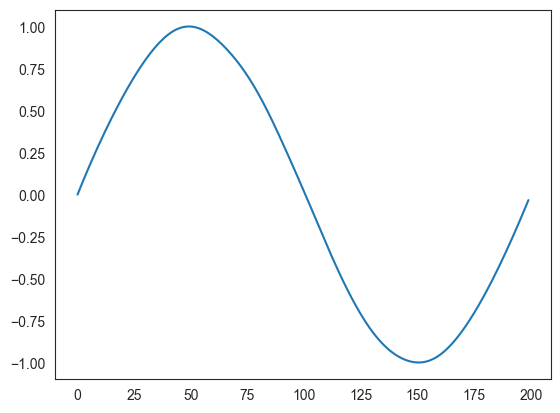

In [13]:
# Plot y_pred at different points in time t in [0, 99]
t = 0

plt.plot(y_pred[:, t])

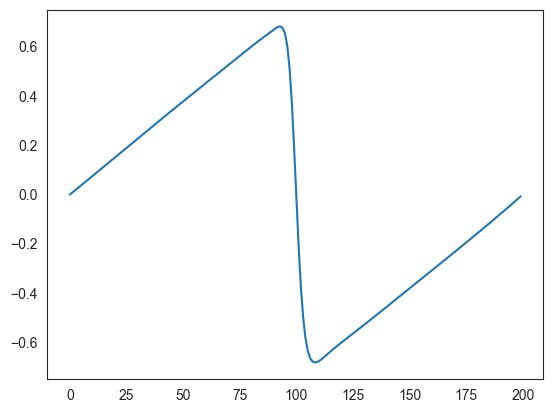

In [14]:
# Plot y_pred at the end of the traning (t=-1 --> last value of t)
plt.plot(y_pred[:, -1])

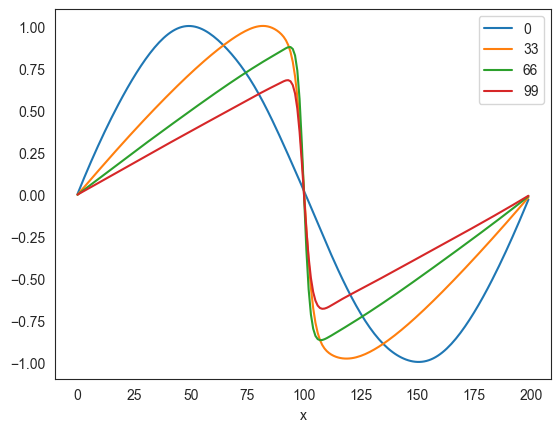

In [15]:
# Plot y_pred for different t

time_step_list = [0, 33, 66, 99]
for t in time_step_list:
    plt.plot(y_pred[:, t])

plt.xlabel("x")
plt.legend(time_step_list)